In [1]:
%load_ext autoreload
%autoreload 2

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions import * 
from extrapolator import VarProIRLS
pd.set_option('display.precision', 18)
pd.set_option('display.max_columns', None)
np.set_printoptions(precision=18)

In [17]:
# Load the reference values file
ref_df = pd.read_table("/home/aldiyar/extrapolation/large-dataset/reference_vals.txt", delim_whitespace=True)

# Define system name mapping
system_mapping = {
    'infBe_1Po-01': 'be_1po',
    'infBe_1Se-01': 'be_1se',
    'infBe_3Po-01': 'be_3po',
    'infBe_3Se-01': 'be_3se',
    'infLi_2Po-01': 'li_2po',
    'infLi_2Se-01': 'li_2se'
}

# Get unique systems
systems = ref_df['system'].unique()

# Process each system
for system in systems: 
    if system not in system_mapping:
        continue
    
    # Filter data for this system
    system_data = ref_df[ref_df['system'] == system]
    
    # Create a dictionary for the uncertainty row
    uncertainty_dict = {'Basis Size': 30000}
    
    # Add each expectation value's uncertainty
    for _, row in system_data.iterrows():
        expectation_value = row['expectation_value']
        uncertainty = row['uncertainty']
        uncertainty_dict[expectation_value] = uncertainty
    
    # Create DataFrame with one row
    err_df = pd.DataFrame([uncertainty_dict])
    
    # Reorder columns:  Basis Size first, then all expectation values in original order
    cols = ['Basis Size'] + [row['expectation_value'] for _, row in system_data.iterrows()]
    err_df = err_df[cols]
    
    # Get the output filename
    output_name = system_mapping[system]
    
    # Save to CSV
    err_df.to_csv(f"{output_name}_err.csv", index=False)
    
    print(f"Created {output_name}_err.csv with shape {err_df.shape}")
    print(f"Columns: {list(err_df.columns)}\n")

print("All error dataframes created successfully!")

Created be_1po_err.csv with shape (1, 21)
Columns: ['Basis Size', 'Energy', 'MV', 'drach_MV', 'OO', '1/r^2_1', '1/r^2_12', '1/r_1', '1/r_12', 'r_1', 'r_12', 'r^2_1', 'r^2_12', 'delta(r_1)', 'delta(r_12)', 'drach_delta(r_1)', 'drach_delta(r_12)', 'prval(r_1)', 'prval(r_12)', 'SO1', 'SO2']

Created be_1se_err.csv with shape (1, 21)
Columns: ['Basis Size', 'Energy', 'MV', 'drach_MV', 'OO', '1/r^2_1', '1/r^2_12', '1/r_1', '1/r_12', 'r_1', 'r_12', 'r^2_1', 'r^2_12', 'delta(r_1)', 'delta(r_12)', 'drach_delta(r_1)', 'drach_delta(r_12)', 'prval(r_1)', 'prval(r_12)', 'SO1', 'SO2']

Created be_3po_err.csv with shape (1, 21)
Columns: ['Basis Size', 'Energy', 'MV', 'drach_MV', 'OO', '1/r^2_1', '1/r^2_12', '1/r_1', '1/r_12', 'r_1', 'r_12', 'r^2_1', 'r^2_12', 'delta(r_1)', 'delta(r_12)', 'drach_delta(r_1)', 'drach_delta(r_12)', 'prval(r_1)', 'prval(r_12)', 'SO1', 'SO2']

Created be_3se_err.csv with shape (1, 21)
Columns: ['Basis Size', 'Energy', 'MV', 'drach_MV', 'OO', '1/r^2_1', '1/r^2_12', '1/r_1'

/tmp/ipykernel_3403/2254193855.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_table is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ref_df = pd.read_table("/home/aldiyar/extrapolation/large-dataset/reference_vals.txt", delim_whitespace=True)


In [ ]:
# def upload_df1(file_path):
#   df = pd.read_csv(file_path)
#   df['basis size'] = df['basis size'].astype(int)

#   return df[2:]

In [3]:
be_1de = upload_df('/home/aldiyar/extrapolation/large-dataset/be_1De.xls')
be_1de = be_1de.drop(columns=['SO1', 'SO2'])
be_1de = be_1de.rename(columns={'Basis Size': 'basis size'})
be_1de_inf = be_1de.loc[be_1de['basis size'] == max(be_1de['basis size'])]
be_1de_init = be_1de.iloc[:-1]
be_1de_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/be_1De_err.xls')
be_1de_err = be_1de_err.drop(columns=['SO1', 'SO2'])


In [4]:
be_3de = upload_df('/home/aldiyar/extrapolation/large-dataset/be_3De.xls')
be_3de = be_3de.rename(columns={'Basis Size': 'basis size'})
be_3de_inf = be_3de.loc[be_3de['basis size'] == max(be_3de['basis size'])]
be_3de_init = be_3de.iloc[:-1]
be_3de_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/be_3De_err.xls')

In [5]:
be_3pe = upload_df('/home/aldiyar/extrapolation/large-dataset/be_3Pe.xls')
be_3pe = be_3pe.rename(columns={'Basis Size': 'basis size'})
be_3pe_inf = be_3pe.loc[be_3pe['basis size'] == max(be_3pe['basis size'])]
be_3pe_init = be_3pe.iloc[:-1]
be_3pe_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/be_3Pe_err.xls')

In [3]:
li_2se = upload_df('/home/aldiyar/extrapolation/large-dataset/Li_2Se.csv')
li_2se = li_2se.drop(columns = ['SO1', 'SO2'])
li_2se = li_2se.rename(columns= {'Basis Size': 'basis size'})
li_2se_inf = li_2se.loc[li_2se['basis size'] == max(li_2se['basis size'])]
li_2se_init = li_2se.iloc[:-1]
li_2se_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/li_2se_err.csv')

In [4]:
be_1se = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_1Se.csv')
be_1se = be_1se.drop(columns = ['SO1', 'SO2'])
be_1se = be_1se.rename(columns= {'Basis Size': 'basis size'})
be_1se_inf = be_1se.loc[be_1se['basis size'] == max(be_1se['basis size'])]
be_1se_init = be_1se.iloc[:-1]
be_1se_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/be_1se_err.csv')

In [17]:
be_3po = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_3Po.csv')
be_3po = be_3po.drop(columns = ['SO1', 'SO2'])
be_3po = be_3po.rename(columns= {'Basis Size': 'basis size'})
be_3po_inf = be_3po.loc[be_3po['basis size'] == max(be_3po['basis size'])]
be_3po_init = be_3po.iloc[:-1]
be_3po_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/be_3po_err.csv')

In [6]:
be_1po = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_1Po.csv')
be_1po = be_1po.drop(columns = ['SO1', 'SO2'])
be_1po = be_1po.rename(columns= {'Basis Size': 'basis size'})
be_1po_inf = be_1po.loc[be_1po['basis size'] == max(be_1po['basis size'])]
be_1po_init = be_1po.iloc[:-1]
be_1po_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/be_1po_err.csv')

In [7]:
li_2po = upload_df('/home/aldiyar/extrapolation/large-dataset/Li_2Po.csv')
li_2po = li_2po.drop(columns = ['SO1', 'SO2'])
li_2po = li_2po.rename(columns= {'Basis Size': 'basis size'})
li_2po_inf = li_2po.loc[li_2po['basis size'] == max(li_2po['basis size'])]
li_2po_init = li_2po.iloc[:-1]
li_2po_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/li_2po_err.csv')

In [8]:
be_3se = upload_df('/home/aldiyar/extrapolation/large-dataset/Be_3Se.csv')
be_3se = be_3se.drop(columns = ['SO1', 'SO2'])
be_3se = be_3se.rename(columns= {'Basis Size': 'basis size'})
be_3se_inf = be_3se.loc[be_3se['basis size'] == max(be_3se['basis size'])]
be_3se_init = be_3se.iloc[:-1]
be_3se_err = pd.read_csv('/home/aldiyar/extrapolation/large-dataset-err/be_3se_err.csv')


--- Fitting Model: exponential ---
Iter  | B (Decay)       | C (Asymptote)   | Weight Ratio             
-----------------------------------------------------------------
0     | 4.9810280520 | -260.8332196065 | 1.986                    
1     | 4.5017144533 | -260.8386632497 | 3.887                    
2     | 4.3816548310 | -260.8391514469 | 7.414                    
3     | 4.3062483594 | -260.8394793186 | 13.480                   
4     | 4.2621608923 | -260.8396892044 | 22.656                   
5     | 4.2375431763 | -260.8398172695 | 34.141                   
6     | 4.2236410808 | -260.8398938071 | 45.521                   
7     | 4.2152234244 | -260.8399399670 | 54.441                   
8     | 4.2095981739 | -260.8399689282 | 60.203                   
9     | 4.2059041359 | -260.8399868486 | 63.456                   
10    | 4.2032938023 | -260.8399986128 | 65.136                   
11    | 4.2013479273 | -260.8400067950 | 65.946                   
12    | 4.2001692944 | -

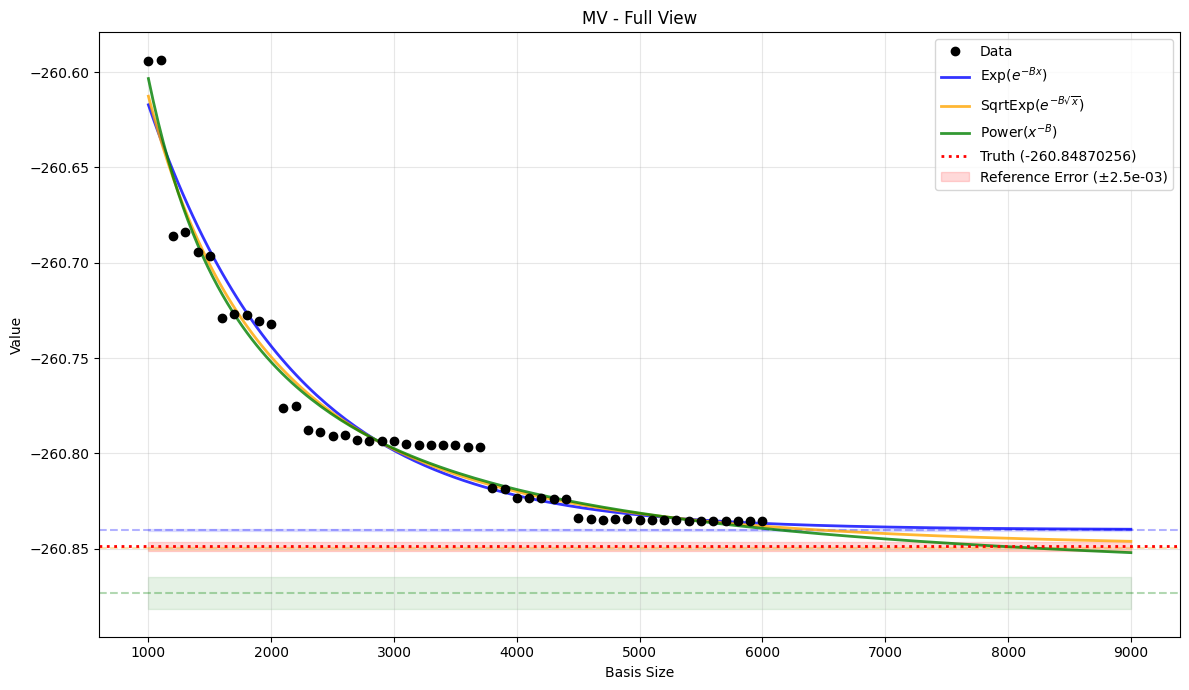

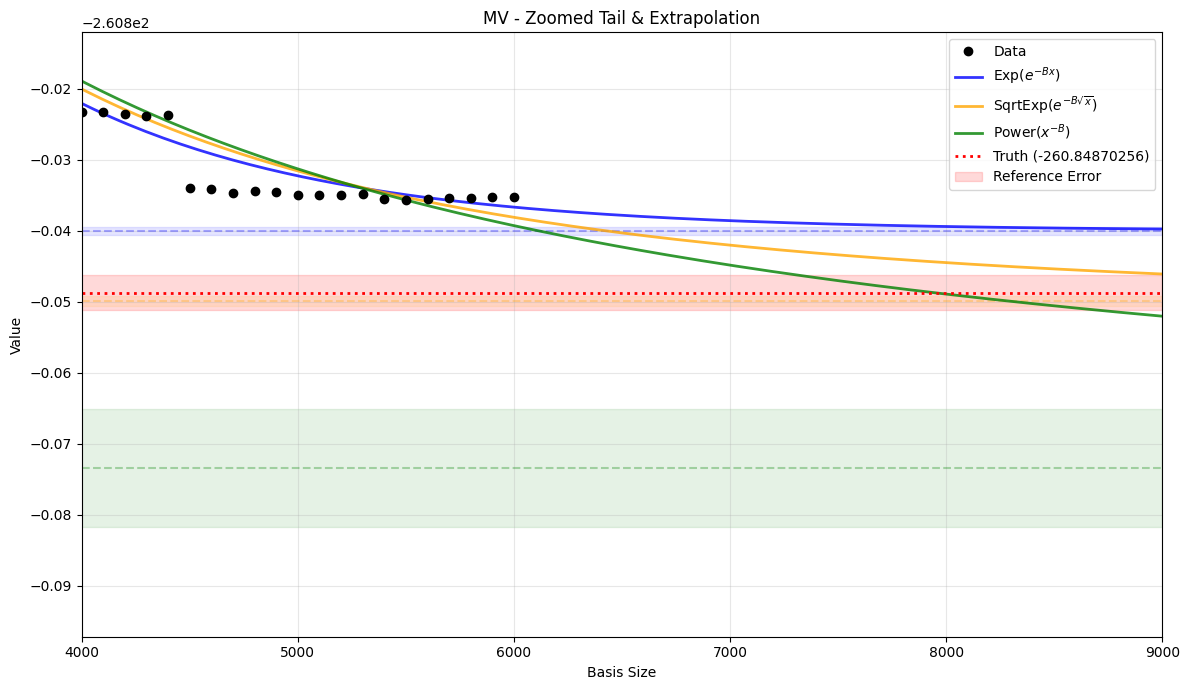

In [44]:
solver = VarProIRLS(be_3pe_init, 'basis size', 'MV', err_df=be_3pe_err)
solver.fit_irls(verbose=True)
solver.plot(truth_val=-260.84870256105)
# solver.plot_ssr_profile(model_type='sqrt_exp')

In [43]:
be_3pe_inf

,basis size,Energy,MV,drach_MV,OO,SO1,SO2,1/r^2_1,1/r^2_12,1/r_1,1/r_12,r_1,r_12,r^2_1,r^2_12,delta(r_1),delta(r_12),drach_delta(r_1),drach_delta(r_12),prval(r_1),prval(r_12)
60,14000,-14.395453741951900639,-260.848702561058019,-260.852634053009978743,-0.53616396039757197,0.310216665044228013,-0.218257609237506006,13.995001161822900215,1.525624186348949918,2.061727264632640111,0.699454791564554035,1.679577485726859942,2.837471428821059849,5.526349093611809593,11.28311524314569958,8.551578168399009527,0.252915350962987007,8.551737133382269818,0.252909346382588995,-221.644996699269995588,-1.085061639359260033


In [10]:
reference_values = pd.read_csv('/home/aldiyar/extrapolation/large-dataset/reference_vals.txt', delim_whitespace=True)

/tmp/ipykernel_3403/4049882052.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  reference_values = pd.read_csv('/home/aldiyar/extrapolation/large-dataset/reference_vals.txt', delim_whitespace=True)


In [11]:
reference_values

,system,expectation_value,ref_value,uncertainty,source
0,infBe_1Po-01,Energy,-14.473451386869198743,0.000000001571315522,our_calc_16400
1,infBe_1Po-01,MV,-266.659088807117598208,0.000015943136020269,our_calc_16400
2,infBe_1Po-01,drach_MV,-266.664462793425059317,0.000005985582845369,our_calc_16400
3,infBe_1Po-01,OO,-0.812091476559140046,0.000000041564738762,our_calc_16400
4,infBe_1Po-01,1/r^2_1,14.216540761971746321,0.000000008542075491,our_calc_16400
...,...,...,...,...,...
115,infLi_2Se-01,drach_delta(r_12),0.181441544289981410,0.000000000004542505,our_calc_12000
116,infLi_2Se-01,prval(r_1),-102.770256511564326729,0.001889366435264605,our_calc_12000
117,infLi_2Se-01,prval(r_12),0.091079437718323997,0.000011833424196001,our_calc_12000
118,infLi_2Se-01,SO1,0.000000000000000000,0.000000000000000000,our_calc_12000


In [160]:
import re
import extrapolator  # your unified_extrapolator module

class SystemExtrapolator:
    """
    Given one system's dataframe with 'basis size' and multiple expectation value columns,
    extrapolate each column to infinity using unified_extrapolator and return the results.
    """

    def __init__(self, df, target_basis_size):
        if "basis size" not in df.columns:
            raise ValueError("DataFrame must contain 'basis size'.")
        self.df = df.copy()
        self.target_basis_size = target_basis_size

    def extrapolate_all(self):
        """
        Extrapolates all columns and returns a dictionary of results.
        This is more efficient as it creates the extrapolator object only once.
        """
        expectation_columns = [c for c in self.df.columns if c != "basis size"]
        
        # --- EFFICIENCY FIX: Create the extrapolator object ONCE per system ---
        extrap = extrapolator.unified_extrapolator(self.df)
        
        all_results = {}

        for col in expectation_columns:
            extrap.fit_column(col, self.target_basis_size)

            # Store all results for this column in a dictionary
            all_results[col] = {
                "exp_inf": extrap.results['exponential'].params['C'].value,
                "exp_sq_inf": extrap.results['exponential_sq'].params['C'].value,
                "power_inf": extrap.results['power'].params['C'].value,
                "exp_unc": extrap.uncertainties['exponential'],
                "exp_sq_unc": extrap.uncertainties['exponential_sq'],
                "power_unc": extrap.uncertainties['power']
            }

        return all_results


def extrapolate_system(df, system_name, target_basis_size):
    """
    Extrapolate all expectation values for a system and return a clean DataFrame of results.
    """
    extr = SystemExtrapolator(df, target_basis_size)
    # This dictionary now holds all the data cleanly, with one entry per column
    results_dict = extr.extrapolate_all()

    rows = []
    # --- CLEANER DATA HANDLING: Iterate through the results dictionary directly ---
    for col, results in results_dict.items():
        rows.append({
            "system": system_name,
            "expectation_value": col,
            # Unpack the results for the column
            "exp_inf": results["exp_inf"],
            "exp_sq_inf": results["exp_sq_inf"],
            "power_inf": results["power_inf"],
            "exp_unc": results["exp_unc"],
            "exp_sq_unc": results["exp_sq_unc"],
            "power_unc": results["power_unc"],
        })
        
    return pd.DataFrame(rows)


def get_target_basis_size(reference_values, system_name):
    """
    Parse basis size from the 'source' column (e.g., our_calc_16400).
    If not found for this expectation, fall back to another row of the same system.
    """
    sys_refs = reference_values[reference_values["system"] == system_name]

    for src in sys_refs["source"].dropna().unique():
        match = re.search(r"our_calc_(\d+)", src)
        if match:
            return int(match.group(1))

    raise ValueError(f"Could not determine target basis size for {system_name}")


# --- Main execution block (remains the same) ---


systems = {
    "infBe_1Po-01": be_1po_init,
    "infBe_1Se-01": be_1se_init,
    "infBe_3Po-01": be_3po_init,
    "infBe_3Se-01": be_3se_init,
    "infLi_2Po-01": li_2po_init,
    "infLi_2Se-01": li_2se_init,
}

all_results = []
for sys_name, df in systems.items():
    target_basis_size = get_target_basis_size(reference_values, sys_name)
    all_results.append(extrapolate_system(df, sys_name, target_basis_size))

extrapolated_df = pd.concat(all_results, ignore_index=True)

# --- Merge with reference_values ---
reference_values = reference_values.merge(
    extrapolated_df,
    on=["system", "expectation_value"],
    how="left"
)

# Replace NaN with 0 if desired
reference_values = reference_values.fillna(0)




--- Fitting Exponential Model ---
  Initial guesses: C=-14.473451, A=0.000028, B=6.962569
  Model type: exp
  No known convergent value provided, using weight power n=1 for Exponential
Fitted parameters:
  C = -14.4734512629 ± 0.0000000061 (asymptote)
  A = 0.0000193528 ± 0.0000010051 (amplitude)
  B = 6.2020963839 ± 0.1304066804 (decay rate)
Parameter signs: C=negative, A=positive, B=positive
Fit quality: χ² = 6.837667e-14, RMSE = 3.661583e-08

--- Fitting Exponential SQ Model ---
  Initial guesses: C=-14.473451, A=0.000028, B=7.848533
  Model type: exp_sq
  No known convergent value provided, using weight power n=1 for Exponential SQ
Fitted parameters:
  C = -14.4734514373 ± 0.0000000189 (asymptote)
  A = 0.0000612295 ± 0.0000034881 (amplitude)
  B = 5.7975067122 ± 0.1172294418 (decay rate)
Parameter signs: C=negative, A=positive, B=positive
Fit quality: χ² = 2.339869e-13, RMSE = 6.773462e-08

--- Fitting Power Law Model ---
  No known convergent value provided, using weight power n

In [161]:

def score_ranks(df):

    df = df.copy()

    # --- Process each row individually to calculate scores and then rank ---
    all_ranks = []
    for index, row in df.iterrows():
        model_scores = {}
        
        # --- Calculate the Information Score for each model in the row ---
        for model_key in ["exp", "exp_sq", "power"]:
            pred_val = row[f'{model_key}_inf']
            unc_val = row[f'{model_key}_unc']
            ref_value = row['ref_value']
            epsilon = 1e-15

            # --- Calculate the three components of the Information Score ---

            # 1. Accuracy Term (Relative Error)
            absolute_error = np.abs(pred_val - ref_value)
            relative_error = absolute_error / (np.abs(ref_value) + epsilon)

            # 2. Sharpness Term (Relative Uncertainty)
            relative_uncertainty = np.abs(unc_val) / (np.abs(pred_val) + epsilon)
            
            # 3. Penalty Multiplier (for Calibration)
            calibration_ratio = absolute_error / (unc_val + epsilon)
            penalty_multiplier = np.maximum(1.0, calibration_ratio)

            # --- Combine components into the Final Score ---
            base_score = relative_error + relative_uncertainty
            final_score = base_score * penalty_multiplier
            
            model_scores[model_key] = final_score
        
        # --- Sort models by their score (lowest is best) to determine rank ---
        sorted_models = sorted(model_scores.items(), key=lambda item: item[1])
        
        # --- Assign ranks (1, 2, 3) based on the sorted order ---
        row_ranks = {model_name: rank + 1 for rank, (model_name, score) in enumerate(sorted_models)}
        all_ranks.append(row_ranks)

    # --- Add the final rank columns to the DataFrame ---
    df['rank_exp'] = [r.get('exp') for r in all_ranks]
    df['rank_exp_sq'] = [r.get('exp_sq') for r in all_ranks]
    df['rank_power'] = [r.get('power') for r in all_ranks]
    
    return df


In [162]:
df_ranked = score_ranks(reference_values)
# df_ranked.drop(columns=['exp_delta', 'exp_sq_delta', 'power_delta'], inplace = True)
df_ranked


,system,expectation_value,ref_value,uncertainty,source,exp_inf,exp_sq_inf,power_inf,exp_unc,exp_sq_unc,power_unc,rank_exp,rank_exp_sq,rank_power
0,infBe_1Po-01,Energy,-14.473451386869198743,0.000000001571315522,our_calc_16400,-14.473451262876102064,-14.473451437265969943,-14.473451470487358250,0.000000006086391113,0.000000018921659848,0.000000009289227592,3,1,2
1,infBe_1Po-01,MV,-266.659088807117598208,0.000015943136020269,our_calc_16400,-266.640288644075553748,-266.700480542132368100,-266.684708846882074340,0.003407352682913715,0.020423636905086487,0.015707273269112379,2,3,1
2,infBe_1Po-01,drach_MV,-266.664462793425059317,0.000005985582845369,our_calc_16400,-266.664260767244456929,-266.660957062279749152,-266.661567448543451064,0.000401968493921374,0.007628647858357485,0.007474417903241771,1,3,2
3,infBe_1Po-01,OO,-0.812091476559140046,0.000000041564738762,our_calc_16400,-0.812091362289512952,-0.812091538941689284,-0.812091241182684720,0.000000011904131184,0.000000116746321178,0.000000097823650200,3,1,2
4,infBe_1Po-01,1/r^2_1,14.216540761971746321,0.000000008542075491,our_calc_16400,14.216539813344393650,14.216541107404104594,14.216539470799897771,0.000000046240493879,0.000000156652012768,0.000135549659273670,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,infLi_2Se-01,drach_delta(r_12),0.181441544289981410,0.000000000004542505,our_calc_12000,0.181441544168078422,0.181441544382429598,0.181441546751045180,0.000000000005707082,0.000000000028787035,0.000000000410720133,2,1,3
116,infLi_2Se-01,prval(r_1),-102.770256511564326729,0.001889366435264605,our_calc_12000,-102.765066305389524359,-102.773847788419374183,-102.772487413011731405,0.000248185985725652,0.001888399939276708,0.001548688269350471,3,2,1
117,infLi_2Se-01,prval(r_12),0.091079437718323997,0.000011833424196001,our_calc_12000,0.090792040044963843,0.091325913183770785,0.091223774490658813,0.000042330783519314,0.000193993614278154,0.000173956676653322,3,2,1
118,infLi_2Se-01,SO1,0.000000000000000000,0.000000000000000000,our_calc_12000,0.000000000000000000,0.000000000000000000,0.000000000000000000,0.000000000000000000,0.000000000000000000,0.000000000000000000,1,2,3


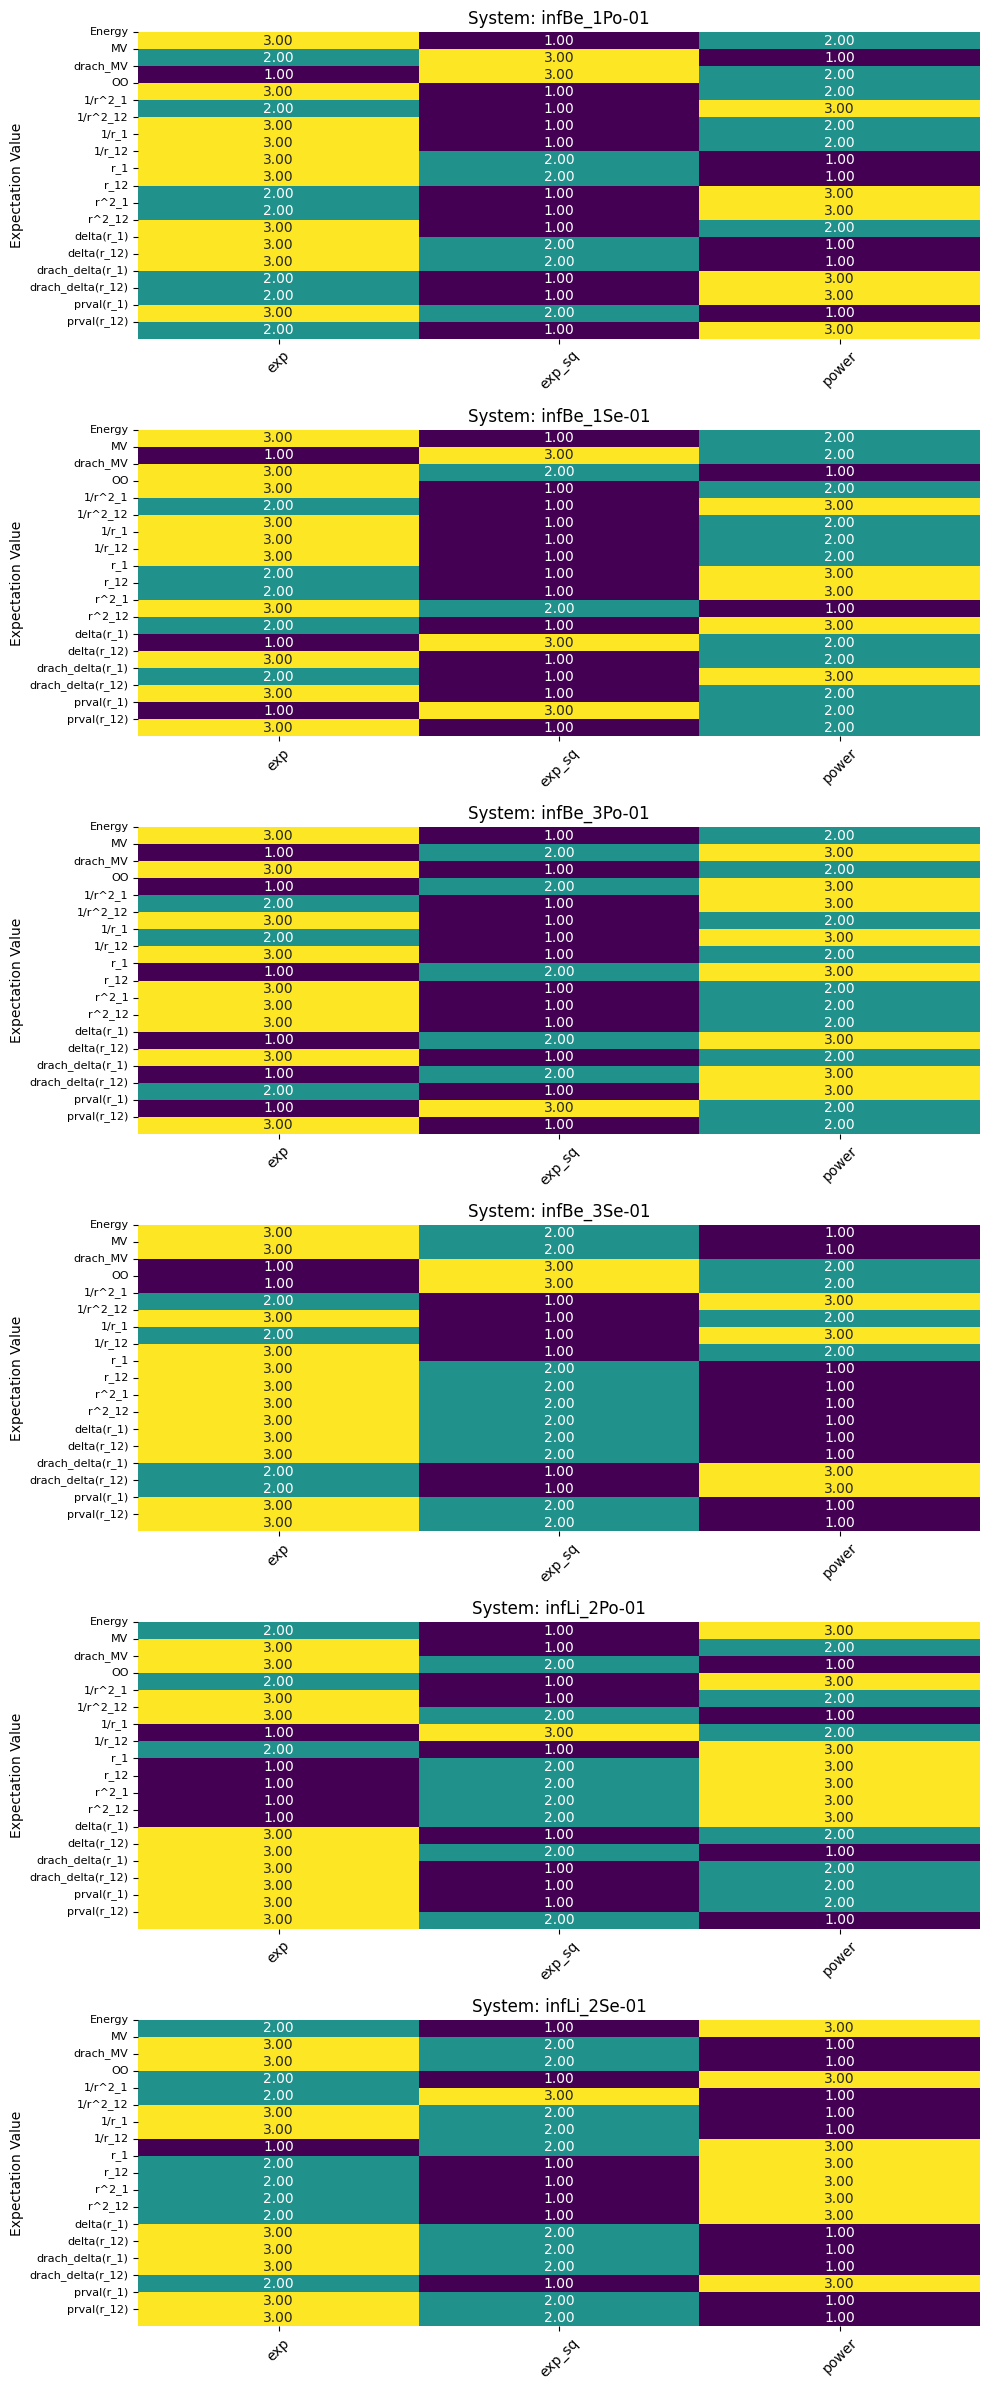

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt

# Melt to long format
df_long = df_ranked.melt(
    id_vars=["system","expectation_value"],
    value_vars=["rank_exp","rank_exp_sq","rank_power"],
    var_name="method", value_name="rank"
)

# Clean method names
df_long["method"] = df_long["method"].str.replace("rank_", "")

# Full list of expectation values
all_expectations = [
    'Energy', 'MV', 'drach_MV', 'OO', '1/r^2_1', '1/r^2_12', '1/r_1',
    '1/r_12', 'r_1', 'r_12', 'r^2_1', 'r^2_12', 'delta(r_1)', 'delta(r_12)',
    'drach_delta(r_1)', 'drach_delta(r_12)', 'prval(r_1)', 'prval(r_12)'
]

# Plot one heatmap per system
systems = df_ranked["system"].unique()
n_systems = len(systems)

fig, axes = plt.subplots(
    n_systems, 1, figsize=(10, max(4*n_systems, 0.4*len(all_expectations)))
)

# Make axes iterable even if n_systems=1
if n_systems == 1:
    axes = [axes]

for ax, system in zip(axes, systems):
    pivot = df_long[df_long["system"]==system].pivot(
        index="expectation_value", columns="method", values="rank"
    )
    pivot = pivot.reindex(all_expectations)  # ensure all rows

    sns.heatmap(
        pivot, cmap="viridis", annot=True, fmt=".2f", cbar=False, ax=ax
    )
    ax.set_title(f"System: {system}")
    ax.set_ylabel("Expectation Value")
    ax.set_xlabel("")

    # Force all labels to show
    ax.set_yticks(range(len(all_expectations)))
    ax.set_yticklabels(all_expectations, fontsize=8)

    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [164]:


def display_rankings(df):

    rank_cols = {
        "Exponential": "rank_exp",
        "Exponential Sqrt": "rank_exp_sq",
        "Power Law": "rank_power"
    }

    summary_data = {}
    for name, col in rank_cols.items():

        summary_data[name] = df[col].value_counts()


    summary_df = pd.DataFrame(summary_data)
    

    summary_df = summary_df.fillna(0).astype(int)
    summary_df.index.name = "Rank"
    summary_df = summary_df.reindex([1, 2, 3]) 


    avg_ranks = {}
    for name, col in rank_cols.items():
        avg_ranks[name] = df[col].mean()
    

    summary_df.loc['Average Rank'] = avg_ranks
    

    overall_winner = min(avg_ranks, key=avg_ranks.get)


    print("--- Model Performance Summary ---")
    print(summary_df)
    print("\n---------------------------------")
    print(f"\n🏆 Overall Best Function (based on lowest average rank): {overall_winner}")
    print("---------------------------------")



In [166]:
display_rankings(df_ranked)

--- Model Performance Summary ---
              Exponential       Exponential Sqrt              Power Law
Rank                                                                   
1                   30.00  58.000000000000000000  32.000000000000000000
2                   30.00  52.000000000000000000  38.000000000000000000
3                   60.00  10.000000000000000000  50.000000000000000000
Average Rank         2.25   1.600000000000000089   2.149999999999999911

---------------------------------

🏆 Overall Best Function (based on lowest average rank): Exponential Sqrt
---------------------------------
